In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_excel('online_retail_II.xlsx')

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
print("Rows :",df.shape[0])
print("Columns:", df.shape[1])

Rows : 525461
Columns: 8


In [6]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [9]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

print(missing)

             Missing_Count  Missing_Percentage
Invoice                  0            0.000000
StockCode                0            0.000000
Description           2928            0.557225
Quantity                 0            0.000000
InvoiceDate              0            0.000000
Price                    0            0.000000
Customer ID         107927           20.539488
Country                  0            0.000000


In [11]:
df[df["Description"].isnull()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [12]:
df[df["Description"].isnull()].shape

(2928, 8)

In [13]:
df[df["Customer ID"].isnull()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [14]:
df[df["Customer ID"].isnull()].shape

(107927, 8)

In [17]:
df[df["Customer ID"].isnull()]["Quantity"].value_counts().head(10)

Quantity
1     65750
2     18214
3      6836
4      3872
5      2069
6      1870
12      873
8       848
7       721
10      701
Name: count, dtype: int64

In [18]:
df[df["Customer ID"].isnull()]["Quantity"].min()

-9600

In [19]:
missing_customer = df[df["Customer ID"].isnull()]
print("Total Missing ID :" , len(missing_customer))
print("Positive quantity:",
      (missing_customer["Quantity"] > 0).sum())

print("Negative quantity:",
      (missing_customer["Quantity"] < 0).sum())

print("Zero quantity:",
      (missing_customer["Quantity"] == 0).sum())

Total Missing ID : 107927
Positive quantity: 105440
Negative quantity: 2487
Zero quantity: 0


In [21]:
df["Transaction_Type"] = np.where(
    df["Quantity"] < 0,
    "Return",
    "Sale"
)

In [22]:
df["Transaction_Type"].value_counts()

Transaction_Type
Sale      513135
Return     12326
Name: count, dtype: int64

In [27]:
missing_customer_returns = df[
      (df["Customer ID"].isnull()) &
      (df["Quantity"] < 0)
]
missing_customer_returns.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,Return
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,Return
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,Return
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,Return
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,Return


In [28]:
missing_customer_returns.shape

(2487, 9)

In [29]:
df[
    (df["Customer ID"].isnull()) &
    (df["Quantity"] == -9600)
]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type
303996,519017,22759,NaN,-9600,2010-08-13 09:14:00,0.0,NaN,United Kingdom,Return


In [30]:
df["Quantity"].describe()

count    525461.000000
mean         10.337667
std         107.424110
min       -9600.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       19152.000000
Name: Quantity, dtype: float64

In [35]:
df_sales = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
].copy()

In [36]:
df_sales[["Quantity","Price"]].describe()

,Quantity,Price
count,511566.000000,511566.000000
mean,11.400150,4.252563
std,86.761177,63.664629
min,1.000000,0.001000
25%,1.000000,1.250000
50%,3.000000,2.100000
75%,10.000000,4.210000
max,19152.000000,25111.090000


In [37]:
print("Negative quantities:",
      (df_sales["Quantity"] <= 0).sum())

print("Zero/negative prices:",
      (df_sales["Price"] <= 0).sum())

Negative quantities: 0
Zero/negative prices: 0


In [39]:
print("Duplicated rows :",df.duplicated().sum())

Duplicated rows : 6865


In [42]:
df[df.duplicated()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,Sale
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom,Sale
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale


In [43]:
print("Duplicate sales rows:",
      df_sales.duplicated().sum())

Duplicate sales rows: 6835


In [44]:
print("Duplicated rows:",df.duplicated().sum())

Duplicated rows: 6865


In [45]:
df[df.duplicated()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,Sale
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom,Sale
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale


In [46]:
print("Duplicate sales rows:",
      df_sales.duplicated().sum())

Duplicate sales rows: 6835


In [47]:
df_sales[df_sales.duplicated(keep=False)].sort_values(
    by = ["Invoice" , "StockCode"]
).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,Sale
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,Sale
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Sale
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,Sale


In [48]:
df_sales = df_sales.drop_duplicates().copy()

In [49]:
print("Remaining duplicates:", df_sales.duplicated().sum())

Remaining duplicates: 0


In [50]:
print("Rows after removing duplicates:", len(df_sales))

Rows after removing duplicates: 504731


In [51]:
print(df.isnull().sum())

Invoice                  0
StockCode                0
Description           2928
Quantity                 0
InvoiceDate              0
Price                    0
Customer ID         107927
Country                  0
Transaction_Type         0
dtype: int64


In [52]:
df[df["Description"].isnull()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,Return
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,Return
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom,Sale
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom,Sale
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom,Return
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom,Return
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom,Sale
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom,Sale
6576,489901,21098,NaN,-200,2009-12-03 09:47:00,0.0,NaN,United Kingdom,Return
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.0,NaN,United Kingdom,Sale


In [53]:
df[df["Description"].isnull()][
    ["Invoice", "StockCode", "Quantity", "Price", "Customer ID", "Country"]
].head(20)

,Invoice,StockCode,Quantity,Price,Customer ID,Country
470,489521,21646,-50,0.0,NaN,United Kingdom
3114,489655,20683,-44,0.0,NaN,United Kingdom
3161,489659,21350,230,0.0,NaN,United Kingdom
3731,489781,84292,17,0.0,NaN,United Kingdom
4296,489806,18010,-770,0.0,NaN,United Kingdom
4566,489821,85049G,-240,0.0,NaN,United Kingdom
6378,489882,35751C,12,0.0,NaN,United Kingdom
6555,489898,79323G,954,0.0,NaN,United Kingdom
6576,489901,21098,-200,0.0,NaN,United Kingdom
6581,489903,21166,48,0.0,NaN,United Kingdom


In [54]:
df_sales[df_sales["Description"].isnull()].shape

(0, 9)

In [55]:
df_sales["Customer ID"].isnull().sum()

np.int64(103815)

In [56]:
df_sales["Quantity"].describe()

count    504731.000000
mean         11.516923
std          87.337497
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64

In [57]:
df_sales["Price"].describe()

count    504731.000000
mean          4.274692
std          64.093333
min           0.001000
25%           1.250000
50%           2.100000
75%           4.210000
max       25111.090000
Name: Price, dtype: float64

In [58]:
print("Missing Description in df_sales:",
      df_sales["Description"].isnull().sum())

Missing Description in df_sales: 0


In [59]:
print("Missing Customer ID in df_sales:",
      df_sales["Customer ID"].isnull().sum())

Missing Customer ID in df_sales: 103815


In [60]:
print("Duplicate rows in df_sales:",
      df_sales.duplicated().sum())

Duplicate rows in df_sales: 0


In [61]:
print("Original dataset:", df.shape)
print("Clean sales dataset:", df_sales.shape)

Original dataset: (525461, 9)
Clean sales dataset: (504731, 9)


In [62]:
df_sales.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale


# Revenue Creation


In [65]:
df_sales["Revenue"] = df_sales["Quantity"] * df_sales["Price"]

In [66]:
df_sales[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [67]:
df_sales["Revenue"].describe()

count    504731.000000
mean         20.351705
std          91.510976
min           0.001000
25%           4.200000
50%          10.200000
75%          17.700000
max       25111.090000
Name: Revenue, dtype: float64

In [68]:
print(
    "Missing Revenue:",
    df_sales["Revenue"].isnull().sum()
)

Missing Revenue: 0


In [69]:
print(df_sales["Quantity"].describe())

count    504731.000000
mean         11.516923
std          87.337497
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64


In [70]:
print(df_sales["Price"].describe())

count    504731.000000
mean          4.274692
std          64.093333
min           0.001000
25%           1.250000
50%           2.100000
75%           4.210000
max       25111.090000
Name: Price, dtype: float64


In [71]:
df_sales["Revenue"] = df_sales["Quantity"] * df_sales["Price"]

print(df_sales["Revenue"].describe())

print(
    "Missing Revenue:",
    df_sales["Revenue"].isnull().sum()
)

count    504731.000000
mean         20.351705
std          91.510976
min           0.001000
25%           4.200000
50%          10.200000
75%          17.700000
max       25111.090000
Name: Revenue, dtype: float64
Missing Revenue: 0


In [72]:
df_sales.sort_values(
    by = "Revenue",
    ascending=False
).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type,Revenue
241827,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,Sale,25111.09
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,Sale,15818.40
517955,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,Sale,13541.33
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,Sale,10953.50
135015,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,Sale,10953.50
372834,525399,M,Manual,1,2010-10-05 11:49:00,10468.80,NaN,United Kingdom,Sale,10468.80
342147,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,Sale,10468.80
358639,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,Sale,10468.80
74356,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,Sale,8985.60
228042,511465,15044A,PINK PAPER PARASOL,3500,2010-06-08 12:59:00,2.55,18008.0,United Kingdom,Sale,8925.00


In [73]:
df_sales.sort_values(
    by="Quantity",
    ascending=False
).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type,Revenue
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark,Sale,1915.20
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,Sale,1296.00
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,Sale,1296.00
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902.0,Denmark,Sale,1274.40
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902.0,Denmark,Sale,1248.00
135030,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,Sale,2500.00
135029,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,Sale,2500.00
135028,502269,21982,PACK OF 12 SUKI TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,Sale,2500.00
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,Sale,2500.00
93677,498152,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,9456,2010-02-17 10:51:00,0.30,13902.0,Denmark,Sale,2836.80


In [74]:
df_sales.sort_values(
    by="Price",
    ascending=False
).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Transaction_Type,Revenue
241827,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,Sale,25111.09
517955,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,Sale,13541.33
135015,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,Sale,10953.50
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,Sale,10953.50
358639,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,Sale,10468.80
372834,525399,M,Manual,1,2010-10-05 11:49:00,10468.80,NaN,United Kingdom,Sale,10468.80
342147,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,Sale,10468.80
74356,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,Sale,8985.60
374227,525473,M,Manual,1,2010-10-05 15:16:00,7044.79,NaN,United Kingdom,Sale,7044.79
129903,501766,M,Manual,1,2010-03-19 11:35:00,6958.17,15760.0,Norway,Sale,6958.17


In [76]:
df_sales["Description"].value_counts().head(30)

Description
WHITE HANGING HEART T-LIGHT HOLDER    3409
REGENCY CAKESTAND 3 TIER              2034
STRAWBERRY CERAMIC TRINKET BOX        1678
PACK OF 72 RETRO SPOT CAKE CASES      1435
ASSORTED COLOUR BIRD ORNAMENT         1435
60 TEATIME FAIRY CAKE CASES           1372
HOME BUILDING BLOCK WORD              1349
JUMBO BAG RED RETROSPOT               1270
LUNCH BAG RED SPOTTY                  1231
JUMBO STORAGE BAG SUKI                1193
PACK OF 60 PINK PAISLEY CAKE CASES    1176
WOODEN FRAME ANTIQUE WHITE            1161
LUNCH BAG  BLACK SKULL.               1139
REX CASH+CARRY JUMBO SHOPPER          1133
LUNCH BAG SUKI  DESIGN                1131
HEART OF WICKER LARGE                 1123
LOVE BUILDING BLOCK WORD              1107
RED HANGING HEART T-LIGHT HOLDER      1087
JUMBO BAG STRAWBERRY                  1073
JUMBO SHOPPER VINTAGE RED PAISLEY     1070
HEART OF WICKER SMALL                 1053
PARTY BUNTING                         1030
HOT WATER BOTTLE TEA AND SYMPATHY     1030

In [77]:
df_sales["StockCode"].value_counts().head(30)

StockCode
85123A    3375
22423     2034
85099B    2000
21212     1887
21232     1678
20725     1558
84879     1435
84991     1372
21754     1349
20914     1205
21931     1193
21080     1192
21977     1176
22383     1166
22139     1146
20727     1139
82494L    1134
21034     1133
22470     1123
21755     1107
21733     1087
48138     1074
22386     1071
22411     1070
20685     1068
22384     1057
85099F    1056
22469     1053
20724     1038
22382     1038
Name: count, dtype: int64

In [78]:
df_sales[
    df_sales["Description"].str.contains(
        "AMAZON|Manual|Adjustment|FEE",
        case=False,
        na=False
    )
][[
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price",
    "Revenue",
    "Customer ID",
    "Country"
]].head(30)

,Invoice,StockCode,Description,Quantity,Price,Revenue,Customer ID,Country
40,489437,37370,RETRO COFFEE MUGS ASSORTED,12,1.25,15.00,15362.0,United Kingdom
306,489488,22301,COFFEE MUG CAT + BIRD DESIGN,2,2.55,5.10,17238.0,United Kingdom
307,489488,22300,COFFEE MUG DOG + BALL DESIGN,3,2.55,7.65,17238.0,United Kingdom
349,489514,21869,POTTING SHED COFFEE MUG,2,1.25,2.50,15311.0,United Kingdom
487,489522,21869,POTTING SHED COFFEE MUG,1,1.25,1.25,15998.0,United Kingdom
499,489522,22300,COFFEE MUG DOG + BALL DESIGN,3,2.55,7.65,15998.0,United Kingdom
500,489522,22301,COFFEE MUG CAT + BIRD DESIGN,3,2.55,7.65,15998.0,United Kingdom
501,489522,22305,COFFEE MUG PINK PAISLEY DESIGN,3,2.55,7.65,15998.0,United Kingdom
502,489522,22304,COFFEE MUG BLUE PAISLEY DESIGN,3,2.55,7.65,15998.0,United Kingdom
503,489522,22302,COFFEE MUG PEARS DESIGN,3,2.55,7.65,15998.0,United Kingdom


In [79]:
df_sales["StockCode"].value_counts().head(30)

StockCode
85123A    3375
22423     2034
85099B    2000
21212     1887
21232     1678
20725     1558
84879     1435
84991     1372
21754     1349
20914     1205
21931     1193
21080     1192
21977     1176
22383     1166
22139     1146
20727     1139
82494L    1134
21034     1133
22470     1123
21755     1107
21733     1087
48138     1074
22386     1071
22411     1070
20685     1068
22384     1057
85099F    1056
22469     1053
20724     1038
22382     1038
Name: count, dtype: int64

In [80]:
df_product_sales = df_sales[
    ~df_sales["Description"].str.contains(
        "AMAZON|Manual|Adjustment|FEE",
        case=False,
        na=False
    )
].copy()

In [81]:
df_sales["Description"].value_counts().head(30)

Description
WHITE HANGING HEART T-LIGHT HOLDER    3409
REGENCY CAKESTAND 3 TIER              2034
STRAWBERRY CERAMIC TRINKET BOX        1678
PACK OF 72 RETRO SPOT CAKE CASES      1435
ASSORTED COLOUR BIRD ORNAMENT         1435
60 TEATIME FAIRY CAKE CASES           1372
HOME BUILDING BLOCK WORD              1349
JUMBO BAG RED RETROSPOT               1270
LUNCH BAG RED SPOTTY                  1231
JUMBO STORAGE BAG SUKI                1193
PACK OF 60 PINK PAISLEY CAKE CASES    1176
WOODEN FRAME ANTIQUE WHITE            1161
LUNCH BAG  BLACK SKULL.               1139
REX CASH+CARRY JUMBO SHOPPER          1133
LUNCH BAG SUKI  DESIGN                1131
HEART OF WICKER LARGE                 1123
LOVE BUILDING BLOCK WORD              1107
RED HANGING HEART T-LIGHT HOLDER      1087
JUMBO BAG STRAWBERRY                  1073
JUMBO SHOPPER VINTAGE RED PAISLEY     1070
HEART OF WICKER SMALL                 1053
PARTY BUNTING                         1030
HOT WATER BOTTLE TEA AND SYMPATHY     1030

In [82]:
df_sales["StockCode"].value_counts().head(30)

StockCode
85123A    3375
22423     2034
85099B    2000
21212     1887
21232     1678
20725     1558
84879     1435
84991     1372
21754     1349
20914     1205
21931     1193
21080     1192
21977     1176
22383     1166
22139     1146
20727     1139
82494L    1134
21034     1133
22470     1123
21755     1107
21733     1087
48138     1074
22386     1071
22411     1070
20685     1068
22384     1057
85099F    1056
22469     1053
20724     1038
22382     1038
Name: count, dtype: int64

In [83]:
special = df_sales[
    df_sales["Description"].str.contains(
        "AMAZON|MANUAL|ADJUST|FEE",
        case=False,
        na=False
    )
]

print("Special transactions:", len(special))

Special transactions: 3631


In [84]:
special[
    ["Invoice", "StockCode", "Description",
     "Quantity", "Price", "Revenue"]
].head(30)

,Invoice,StockCode,Description,Quantity,Price,Revenue
40,489437,37370,RETRO COFFEE MUGS ASSORTED,12,1.25,15.00
306,489488,22301,COFFEE MUG CAT + BIRD DESIGN,2,2.55,5.10
307,489488,22300,COFFEE MUG DOG + BALL DESIGN,3,2.55,7.65
349,489514,21869,POTTING SHED COFFEE MUG,2,1.25,2.50
487,489522,21869,POTTING SHED COFFEE MUG,1,1.25,1.25
499,489522,22300,COFFEE MUG DOG + BALL DESIGN,3,2.55,7.65
500,489522,22301,COFFEE MUG CAT + BIRD DESIGN,3,2.55,7.65
501,489522,22305,COFFEE MUG PINK PAISLEY DESIGN,3,2.55,7.65
502,489522,22304,COFFEE MUG BLUE PAISLEY DESIGN,3,2.55,7.65
503,489522,22302,COFFEE MUG PEARS DESIGN,3,2.55,7.65


In [85]:
special["Description"].value_counts()

Description
Manual                                 555
COFFEE MUG CAT + BIRD DESIGN           414
RETRO COFFEE MUGS ASSORTED             380
COFFEE MUG DOG + BALL DESIGN           349
SET 3 RED SPOT TIN TEA,COFFEE,SUGAR    306
COFFEE MUG APPLES DESIGN               279
COFFEE MUG PEARS  DESIGN               186
KENSINGTON COFFEE SET                  153
COFFEE MUG BLUE PAISLEY DESIGN         115
POTTING SHED COFFEE MUG                112
COFFEE MUG PINK PAISLEY DESIGN          96
ENAMEL PINK COFFEE CONTAINER            96
SET 3 RETROSPOT TEA,COFFEE,SUGAR        84
VINTAGE GLASS COFFEE CADDY              84
COFFEE SCENT PILLAR CANDLE              63
RED  SPOTTY COFFEE  MUG                 53
ENAMEL BLUE RIM COFFEE CONTAINER        43
BLUE CHALET BIRDFEEDER                  36
BLACK TEA,COFFEE,SUGAR JARS             36
BLUE  SPOTTY  COFFEE MUG                35
WHITE TEA,COFFEE,SUGAR JARS             30
OLIVE CHALET BIRDFEEDER                 26
Adjustment by john on 26/01/2010 16     20

# Feature Engineering

In [86]:
df_sales["Year"] = df_sales["InvoiceDate"].dt.year
df_sales["Month"] = df_sales["InvoiceDate"].dt.month
df_sales["Month_Name"] = df_sales["InvoiceDate"].dt.month_name()


In [87]:
df_sales[
    ["InvoiceDate", "Year", "Month", "Month_Name"]
].head()

,InvoiceDate,Year,Month,Month_Name
0,2009-12-01 07:45:00,2009,12,December
1,2009-12-01 07:45:00,2009,12,December
2,2009-12-01 07:45:00,2009,12,December
3,2009-12-01 07:45:00,2009,12,December
4,2009-12-01 07:45:00,2009,12,December


# Create a Year-Month column

In [88]:
df_sales["Year_Month"] = (
    df_sales["InvoiceDate"].dt.to_period("M")
)

In [89]:
df_sales[["InvoiceDate", "Year_Month"]].head()

,InvoiceDate,Year_Month
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


# Create Day of Week

In [90]:
df_sales["Day_Of_Week"] = (
    df_sales["InvoiceDate"].dt.day_name()
)

In [93]:
df_sales["Day_Of_Week"].value_counts()

Day_Of_Week
Thursday     95039
Monday       90906
Tuesday      90522
Wednesday    87146
Sunday       72176
Friday       68542
Saturday       400
Name: count, dtype: int64

# Create Hour

In [95]:
df_sales["Hour"] = (
    df_sales["InvoiceDate"].dt.hour
)

In [96]:
df_sales["Hour"].value_counts().sort_index()

Hour
7       685
8      6879
9     33306
10    42546
11    61321
12    78010
13    74932
14    71595
15    55357
16    37685
17    27756
18     8553
19     4921
20     1185
Name: count, dtype: int64

In [97]:
df_sales["Year"] = df_sales["InvoiceDate"].dt.year

df_sales["Month"] = df_sales["InvoiceDate"].dt.month

df_sales["Month_Name"] = df_sales["InvoiceDate"].dt.month_name()

df_sales["Year_Month"] = (
    df_sales["InvoiceDate"].dt.to_period("M")
)

df_sales["Day_of_Week"] = (
    df_sales["InvoiceDate"].dt.day_name()
)

df_sales["Hour"] = df_sales["InvoiceDate"].dt.hour

In [98]:
df_sales[
    ["InvoiceDate", "Year", "Month", "Month_Name",
     "Year_Month", "Day_of_Week", "Hour"]
].head()

,InvoiceDate,Year,Month,Month_Name,Year_Month,Day_of_Week,Hour
0,2009-12-01 07:45:00,2009,12,December,2009-12,Tuesday,7
1,2009-12-01 07:45:00,2009,12,December,2009-12,Tuesday,7
2,2009-12-01 07:45:00,2009,12,December,2009-12,Tuesday,7
3,2009-12-01 07:45:00,2009,12,December,2009-12,Tuesday,7
4,2009-12-01 07:45:00,2009,12,December,2009-12,Tuesday,7


# BASIC BUSINESS KPI'S

In [99]:
total_revenue = df_sales["Revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 10272136.234000001


In [100]:
total_units = df_sales["Quantity"].sum()
print("Total Units:", total_units)

Total Units: 5812948


In [101]:
total_transactions = df_sales["Invoice"].nunique()

print("Total Transactions:", total_transactions)

Total Transactions: 20952


In [102]:
total_customers = df_sales["Customer ID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 4312


In [103]:
total_products = df_sales["StockCode"].nunique()

print("Total Products:", total_products)

Total Products: 4251


In [104]:
total_countries = df_sales["Country"].nunique()

print("Total Countries:", total_countries)

Total Countries: 40


# Average Order Value

In [105]:
order_revenue = (
    df_sales.groupby("Invoice")["Revenue"]
    .sum()
)

In [106]:
average_order_value = order_revenue.mean()
print("Average Order Value:", average_order_value)

Average Order Value: 490.2699615311188


# KPI SUMMARY

In [109]:
kpi = {
    "Total Revenue": df_sales["Revenue"].sum(),
    "Total Units Sold": df_sales["Quantity"].sum(),
    "Total Transactions": df_sales["Invoice"].nunique(),
    "Total Customers": df_sales["Customer ID"].nunique(),
    "Total Products": df_sales["StockCode"].nunique(),
    "Total Countries": df_sales["Country"].nunique(),
    "Average Order Value": order_revenue.mean()
}
for key,value in kpi.items():
    print(f"{key}: {value:,.2f}")

Total Revenue: 10,272,136.23
Total Units Sold: 5,812,948.00
Total Transactions: 20,952.00
Total Customers: 4,312.00
Total Products: 4,251.00
Total Countries: 40.00
Average Order Value: 490.27


# MONTHLY REVENUE

In [110]:
monthly_revenue = (
    df_sales.groupby("Year_Month")["Revenue"]
    .sum()
    .reset_index()
)
print(monthly_revenue)

   Year_Month      Revenue
0     2009-12   822483.950
1     2010-01   651155.112
2     2010-02   551878.296
3     2010-03   830915.261
4     2010-04   678875.252
5     2010-05   657705.500
6     2010-06   749537.310
7     2010-07   648810.270
8     2010-08   695251.910
9     2010-09   921696.991
10    2010-10  1161902.220
11    2010-11  1464293.142
12    2010-12   437631.020


# PLOT MONTHLY REVENUE

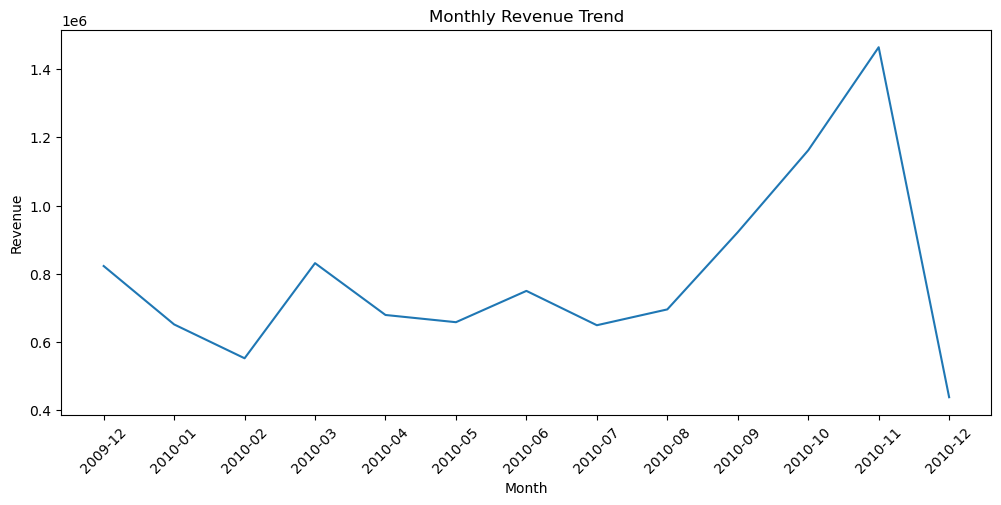

In [112]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue["Year_Month"].astype(str),
    monthly_revenue["Revenue"]
)
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.show()

#Find the best and worst months

In [113]:
monthly_revenue.sort_values(
    "Revenue",ascending=False
).head(5)

,Year_Month,Revenue
11,2010-11,1464293.142
10,2010-10,1161902.220
9,2010-09,921696.991
3,2010-03,830915.261
0,2009-12,822483.950


In [114]:
monthly_revenue.sort_values(
    "Revenue",ascending=True
).head(5)

,Year_Month,Revenue
12,2010-12,437631.020
2,2010-02,551878.296
7,2010-07,648810.270
1,2010-01,651155.112
5,2010-05,657705.500


# Monthly Transaction Volume

In [116]:
monthly_transactions = (
    df_sales.groupby("Year_Month")["Revenue"]
    .nunique()
    .reset_index(name="Transactions")
)
print(monthly_transactions)

   Year_Month  Transactions
0     2009-12          1298
1     2010-01          1347
2     2010-02          1051
3     2010-03          1344
4     2010-04          1149
5     2010-05          1187
6     2010-06          1269
7     2010-07          1120
8     2010-08          1299
9     2010-09          1297
10    2010-10          1492
11    2010-11          1814
12    2010-12          1091


# PLOT

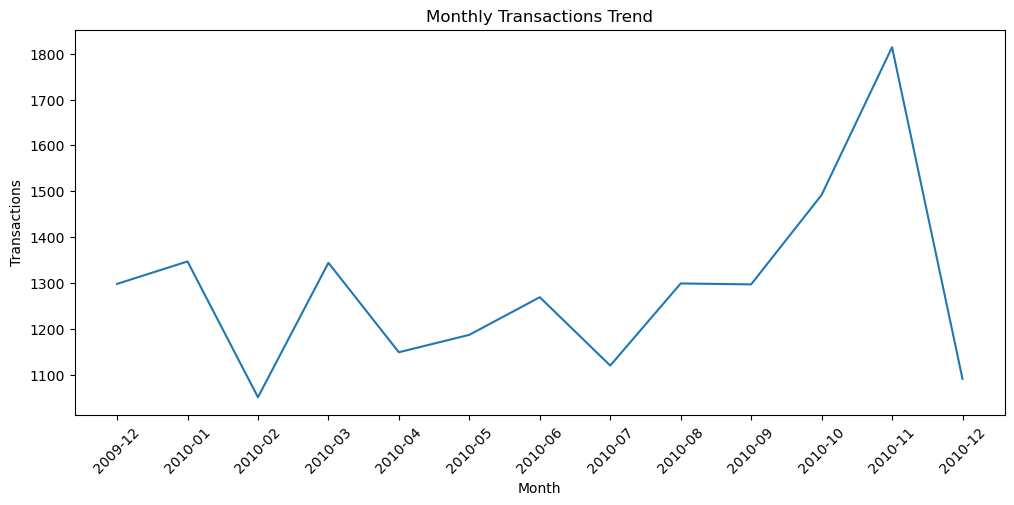

In [117]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue["Year_Month"].astype(str),
    monthly_transactions["Transactions"]
)
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.title("Monthly Transactions Trend")
plt.show()

# Revenue by Day of Week

In [118]:
day_revenue = (
    df_sales.groupby("Day_Of_Week")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(day_revenue)

Day_Of_Week
Thursday     2097097.802
Tuesday      2002003.301
Monday       1860809.825
Wednesday    1745382.103
Friday       1533319.022
Sunday       1023721.131
Saturday        9803.050
Name: Revenue, dtype: float64


# PLOT

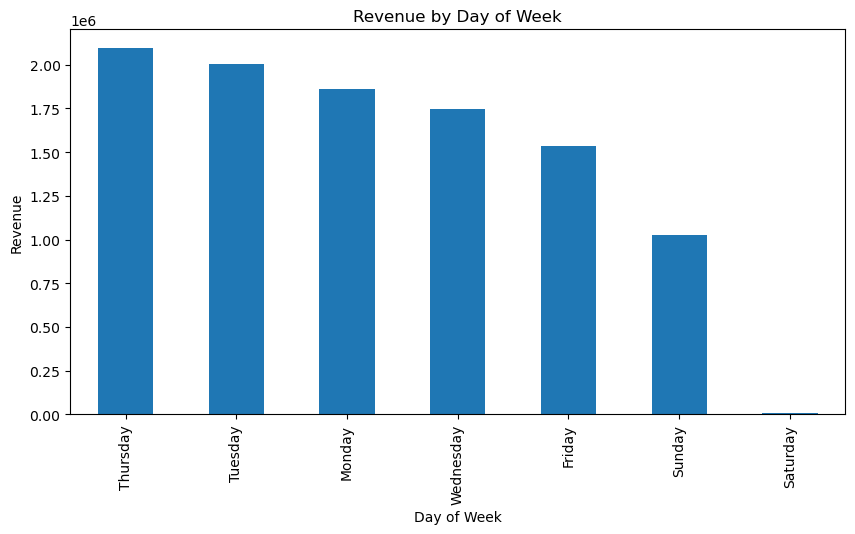

In [120]:
day_revenue.plot(kind="bar",figsize=(10,5))
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.title("Revenue by Day of Week")
plt.show()

# Revenue by Hour

In [121]:
hour_revenue = (
    df_sales.groupby("Hour")["Revenue"]
    .sum()
    
)
print(hour_revenue)

Hour
7       45173.360
8      248940.430
9      811807.660
10    1180711.352
11    1339629.933
12    1459647.691
13    1330157.834
14    1199013.910
15    1121576.882
16     884153.701
17     416238.591
18     136836.100
19      77876.440
20      20372.350
Name: Revenue, dtype: float64


# PLOT

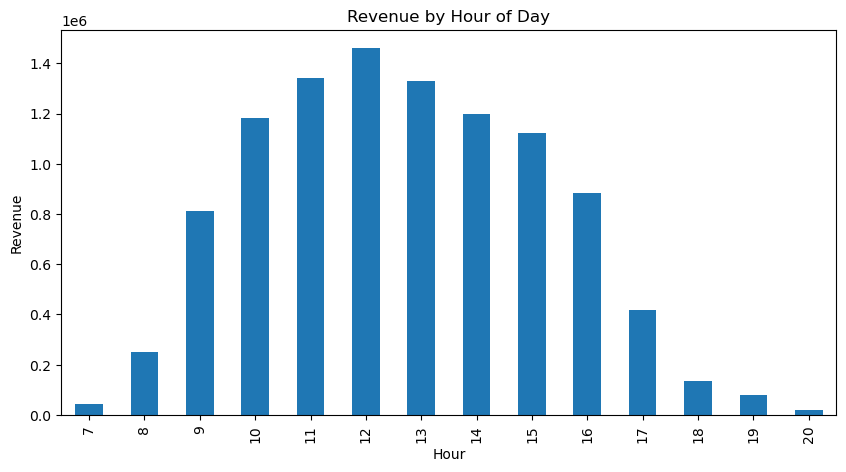

In [123]:
hour_revenue.plot(kind="bar",figsize=(10,5))
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.title("Revenue by Hour of Day")
plt.show()

In [124]:
total_revenue = df_sales["Revenue"].sum()
total_units = df_sales["Quantity"].sum()
total_transactions = df_sales["Invoice"].nunique()
total_customers = df_sales["Customer ID"].nunique()
total_products = df_sales["StockCode"].nunique()
total_countries = df_sales["Country"].nunique()

order_revenue = df_sales.groupby("Invoice")["Revenue"].sum()
average_order_value = order_revenue.mean()

print("Total Revenue:", total_revenue)
print("Total Units:", total_units)
print("Total Transactions:", total_transactions)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Total Countries:", total_countries)
print("Average Order Value:", average_order_value)

Total Revenue: 10272136.234000001
Total Units: 5812948
Total Transactions: 20952
Total Customers: 4312
Total Products: 4251
Total Countries: 40
Average Order Value: 490.2699615311188


# How does revenue change over time?

In [125]:
monthly_revenue = (
    df_sales.groupby("Year_Month")["Revenue"]
    .sum()
    .reset_index()
)

print(monthly_revenue)

   Year_Month      Revenue
0     2009-12   822483.950
1     2010-01   651155.112
2     2010-02   551878.296
3     2010-03   830915.261
4     2010-04   678875.252
5     2010-05   657705.500
6     2010-06   749537.310
7     2010-07   648810.270
8     2010-08   695251.910
9     2010-09   921696.991
10    2010-10  1161902.220
11    2010-11  1464293.142
12    2010-12   437631.020


In [126]:
print(
    monthly_revenue
    .sort_values("Revenue", ascending=False)
    .head(5)
)

   Year_Month      Revenue
11    2010-11  1464293.142
10    2010-10  1161902.220
9     2010-09   921696.991
3     2010-03   830915.261
0     2009-12   822483.950


In [127]:
print(
    monthly_revenue
    .sort_values("Revenue", ascending=True)
    .head(5)
)

   Year_Month     Revenue
12    2010-12  437631.020
2     2010-02  551878.296
7     2010-07  648810.270
1     2010-01  651155.112
5     2010-05  657705.500


# Create the revenue trend chart

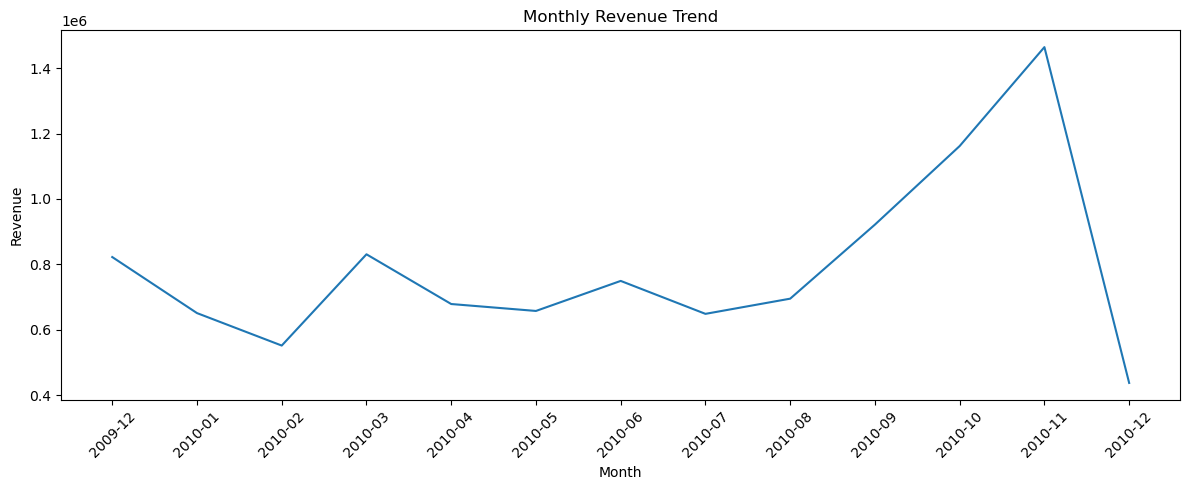

In [128]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Year_Month"].astype(str),
    monthly_revenue["Revenue"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.tight_layout()
plt.show()

In [ ]:
# REVENUE VS TRANSACTIONS

In [129]:
monthly_transactions = (
    df_sales.groupby("Year_Month")["Invoice"]
    .nunique()
    .reset_index(name="Transactions")
)

print(monthly_transactions)

   Year_Month  Transactions
0     2009-12          1682
1     2010-01          1105
2     2010-02          1202
3     2010-03          1681
4     2010-04          1462
5     2010-05          1500
6     2010-06          1645
7     2010-07          1529
8     2010-08          1425
9     2010-09          1839
10    2010-10          2301
11    2010-11          2747
12    2010-12           834


# Monthly Average Order Value

In [130]:
monthly_aov = (
    df_sales.groupby("Year_Month")
    .agg(
        Revenue=("Revenue","sum"),
        Transactions=("Invoice","nunique")
    )
    .reset_index()
)
monthly_aov["AOV"] = (
    monthly_aov["Revenue"]/monthly_aov["Transactions"]
)
print(monthly_aov)

   Year_Month      Revenue  Transactions         AOV
0     2009-12   822483.950          1682  488.991647
1     2010-01   651155.112          1105  589.280644
2     2010-02   551878.296          1202  459.133358
3     2010-03   830915.261          1681  494.298192
4     2010-04   678875.252          1462  464.346958
5     2010-05   657705.500          1500  438.470333
6     2010-06   749537.310          1645  455.645781
7     2010-07   648810.270          1529  424.336344
8     2010-08   695251.910          1425  487.896077
9     2010-09   921696.991          1839  501.194666
10    2010-10  1161902.220          2301  504.955332
11    2010-11  1464293.142          2747  533.051744
12    2010-12   437631.020           834  524.737434


In [131]:
monthly_revenue = (
    df_sales.groupby("Year_Month")["Revenue"]
    .sum()
    .reset_index()
)

print(monthly_revenue)

print("\nTop 5 Months:")
print(
    monthly_revenue
    .sort_values("Revenue", ascending=False)
    .head(5)
)

print("\nBottom 5 Months:")
print(
    monthly_revenue
    .sort_values("Revenue", ascending=True)
    .head(5)
)

   Year_Month      Revenue
0     2009-12   822483.950
1     2010-01   651155.112
2     2010-02   551878.296
3     2010-03   830915.261
4     2010-04   678875.252
5     2010-05   657705.500
6     2010-06   749537.310
7     2010-07   648810.270
8     2010-08   695251.910
9     2010-09   921696.991
10    2010-10  1161902.220
11    2010-11  1464293.142
12    2010-12   437631.020

Top 5 Months:
   Year_Month      Revenue
11    2010-11  1464293.142
10    2010-10  1161902.220
9     2010-09   921696.991
3     2010-03   830915.261
0     2009-12   822483.950

Bottom 5 Months:
   Year_Month     Revenue
12    2010-12  437631.020
2     2010-02  551878.296
7     2010-07  648810.270
1     2010-01  651155.112
5     2010-05  657705.500


#revenue pattern is:

# Highest: November 2010 → 1.46M
# 2nd: October 2010 → 1.16M
# 3rd: September 2010 → 0.92M
# Lowest: December 2010 → 0.44M

# Visualize the trend

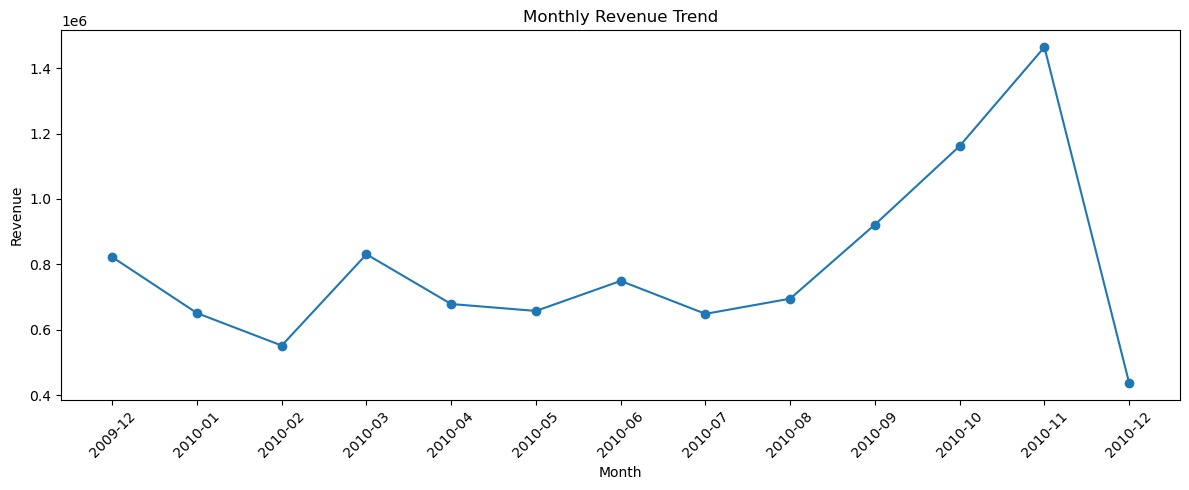

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Year_Month"].astype(str),
    monthly_revenue["Revenue"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.tight_layout()
plt.show()

# That last point is important because your dataset ends on December 9, 2010, so December is almost certainly a partial month.
# Check whether December is incomplete

In [134]:
df_sales["InvoiceDate"].max()

Timestamp('2010-12-09 20:01:00')

In [135]:
df_sales["InvoiceDate"].min()

Timestamp('2009-12-01 07:45:00')

#Analyze transactions alongside revenue

In [136]:
monthly_transactions = (
    df_sales.groupby("Year_Month")["Invoice"]
    .nunique()
    .reset_index(name="Transactions")
)

print(monthly_transactions)

   Year_Month  Transactions
0     2009-12          1682
1     2010-01          1105
2     2010-02          1202
3     2010-03          1681
4     2010-04          1462
5     2010-05          1500
6     2010-06          1645
7     2010-07          1529
8     2010-08          1425
9     2010-09          1839
10    2010-10          2301
11    2010-11          2747
12    2010-12           834


In [137]:
monthly_analysis = (
    df_sales.groupby("Year_Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("Invoice", "nunique")
    )
    .reset_index()
)

monthly_analysis["AOV"] = (
    monthly_analysis["Revenue"] /
    monthly_analysis["Transactions"]
)

print(monthly_analysis)

   Year_Month      Revenue  Transactions         AOV
0     2009-12   822483.950          1682  488.991647
1     2010-01   651155.112          1105  589.280644
2     2010-02   551878.296          1202  459.133358
3     2010-03   830915.261          1681  494.298192
4     2010-04   678875.252          1462  464.346958
5     2010-05   657705.500          1500  438.470333
6     2010-06   749537.310          1645  455.645781
7     2010-07   648810.270          1529  424.336344
8     2010-08   695251.910          1425  487.896077
9     2010-09   921696.991          1839  501.194666
10    2010-10  1161902.220          2301  504.955332
11    2010-11  1464293.142          2747  533.051744
12    2010-12   437631.020           834  524.737434


# MOM Growth

In [141]:
monthly_analysis["Revenue_Growth_%"] =(
    monthly_analysis["Revenue"]
    .pct_change() * 100
)
print(monthly_analysis)

   Year_Month      Revenue  Transactions         AOV  Revenue_Growth_%
0     2009-12   822483.950          1682  488.991647               NaN
1     2010-01   651155.112          1105  589.280644        -20.830660
2     2010-02   551878.296          1202  459.133358        -15.246262
3     2010-03   830915.261          1681  494.298192         50.561322
4     2010-04   678875.252          1462  464.346958        -18.297896
5     2010-05   657705.500          1500  438.470333         -3.118357
6     2010-06   749537.310          1645  455.645781         13.962451
7     2010-07   648810.270          1529  424.336344        -13.438563
8     2010-08   695251.910          1425  487.896077          7.157969
9     2010-09   921696.991          1839  501.194666         32.570221
10    2010-10  1161902.220          2301  504.955332         26.061193
11    2010-11  1464293.142          2747  533.051744         26.025505
12    2010-12   437631.020           834  524.737434        -70.113155


In [142]:
monthly_analysis[
    ["Year_Month", "Revenue", "Revenue_Growth_%"]
]

,Year_Month,Revenue,Revenue_Growth_%
0,2009-12,822483.950,NaN
1,2010-01,651155.112,-20.830660
2,2010-02,551878.296,-15.246262
3,2010-03,830915.261,50.561322
4,2010-04,678875.252,-18.297896
5,2010-05,657705.500,-3.118357
6,2010-06,749537.310,13.962451
7,2010-07,648810.270,-13.438563
8,2010-08,695251.910,7.157969
9,2010-09,921696.991,32.570221


# Top 10 by quantity

In [143]:
top_products_quantity = (
    df_sales.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_products_quantity)

Description
WHITE HANGING HEART T-LIGHT HOLDER    58691
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54947
BROCADE RING PURSE                    48374
PACK OF 72 RETRO SPOT CAKE CASES      46728
ASSORTED COLOUR BIRD ORNAMENT         45228
60 TEATIME FAIRY CAKE CASES           36348
PACK OF 60 PINK PAISLEY CAKE CASES    31805
JUMBO BAG RED RETROSPOT               30746
SMALL POPCORN HOLDER                  29773
STRAWBERRY CERAMIC TRINKET BOX        27059
Name: Quantity, dtype: int64


# Top 10 by revenue

In [144]:
top_products_revenue = (
    df_sales.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_products_revenue)

Description
Manual                                 262963.43
REGENCY CAKESTAND 3 TIER               169912.76
WHITE HANGING HEART T-LIGHT HOLDER     160345.63
DOTCOM POSTAGE                         116408.71
ASSORTED COLOUR BIRD ORNAMENT           72890.19
PAPER CHAIN KIT 50'S CHRISTMAS          58127.30
JUMBO BAG RED RETROSPOT                 56480.46
PARTY BUNTING                           49664.12
POSTAGE                                 49477.54
ROTATING SILVER ANGELS T-LIGHT HLDR     47954.49
Name: Revenue, dtype: float64


# PRODUCT PERFORMANCE ANALYSIS

In [145]:
non_product = [
    "Manual",
    "DOTCOM POSTAGE",
    "POSTAGE",
    "AMAZON FEE"
]
df_product = df_sales[
~df_sales["Description"].isin(non_product)
].copy()

In [146]:
print("Original sales rows:", len(df_sales))
print("Product sales rows:", len(df_product))

Original sales rows: 504731
Product sales rows: 502685


In [147]:
df_product["Description"].isin(non_product).sum()

np.int64(0)

# Compare Quantity vs Revenue

In [151]:
product_summary = (
    df_product.groupby("Description")
    .agg(
        Units_Sold=("Quantity","sum"),
        Revenue=("Revenue","sum"),
        Transactions=("Invoice","nunique")
               
    )
               .reset_index()
)
product_summary["Avg_Selling_Price"] = (
    product_summary["Revenue"] /
    product_summary["Units_Sold"]
)

product_summary["Revenue_%"] = (
    product_summary["Revenue"] /
    product_summary["Revenue"].sum() * 100
)
product_summary.sort_values(
    "Revenue",
    ascending=False
).head(10)

,Description,Units_Sold,Revenue,Transactions,Avg_Selling_Price,Revenue_%
3325,REGENCY CAKESTAND 3 TIER,13685,169912.76,2019,12.415985,1.729737
4345,WHITE HANGING HEART T-LIGHT HOLDER,58691,160345.63,3315,2.732031,1.632342
268,ASSORTED COLOUR BIRD ORNAMENT,45228,72890.19,1412,1.611616,0.742033
2737,PAPER CHAIN KIT 50'S CHRISTMAS,17205,58127.30,957,3.378512,0.591745
2123,JUMBO BAG RED RETROSPOT,30746,56480.46,1246,1.837002,0.574980
2751,PARTY BUNTING,10079,49664.12,1013,4.927485,0.505588
3446,ROTATING SILVER ANGELS T-LIGHT HLDR,23037,47954.49,347,2.081629,0.488184
1334,EDWARDIAN PARASOL NATURAL,7469,36925.26,628,4.943802,0.375905
2127,JUMBO BAG STRAWBERRY,20002,36732.16,1057,1.836424,0.373939
4272,VINTAGE UNION JACK BUNTING,4144,36023.71,829,8.692980,0.366727


# COUNTRY ANALYSIS

# REVENUE BY COUNTRY

In [152]:
country_revenue = (
    df_sales.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print(country_revenue.head(10))

          Country      Revenue
0  United Kingdom  8812685.403
1            EIRE   380909.570
2     Netherlands   268784.350
3         Germany   202025.391
4          France   147103.140
5          Sweden    53501.990
6         Denmark    50906.850
7           Spain    47568.650
8     Switzerland    43921.390
9       Australia    31446.800


# Transactions by Country

In [154]:
country_transactions = (
    df_sales.groupby("Country")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Transactions")
)

print(country_transactions.head(10))

          Country  Transactions
0  United Kingdom         19291
1            EIRE           348
2         Germany           347
3          France           241
4     Netherlands           135
5          Sweden            69
6           Spain            66
7         Belgium            52
8        Portugal            41
9       Australia            40


# Customers by Country

In [155]:
country_customers = (
    df_sales.groupby("Country")["Customer ID"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Customers")
)

print(country_customers.head(10))

          Country  Customers
0  United Kingdom       3969
1         Germany         67
2          France         47
3           Spain         25
4     Netherlands         22
5        Portugal         18
6         Belgium         17
7          Sweden         16
8       Australia         15
9     Switzerland         14


# Country AOV

In [156]:
country_analysis = (
    df_sales.groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

country_analysis["AOV"] = (
    country_analysis["Revenue"] /
    country_analysis["Transactions"]
)

print(
    country_analysis
    .sort_values("Revenue", ascending=False)
    .head(10)
)

           Country      Revenue  Transactions  Customers          AOV
37  United Kingdom  8812685.403         19291       3969   456.828853
10            EIRE   380909.570           348          5  1094.567730
24     Netherlands   268784.350           135         22  1990.995185
13         Germany   202025.391           347         67   582.205738
12          France   147103.140           241         47   610.386473
32          Sweden    53501.990            69         16   775.391159
9          Denmark    50906.850            26          9  1957.955769
31           Spain    47568.650            66         25   720.737121
33     Switzerland    43921.390            40         14  1098.034750
0        Australia    31446.800            40         15   786.170000


# 📊 Create the first Country chart

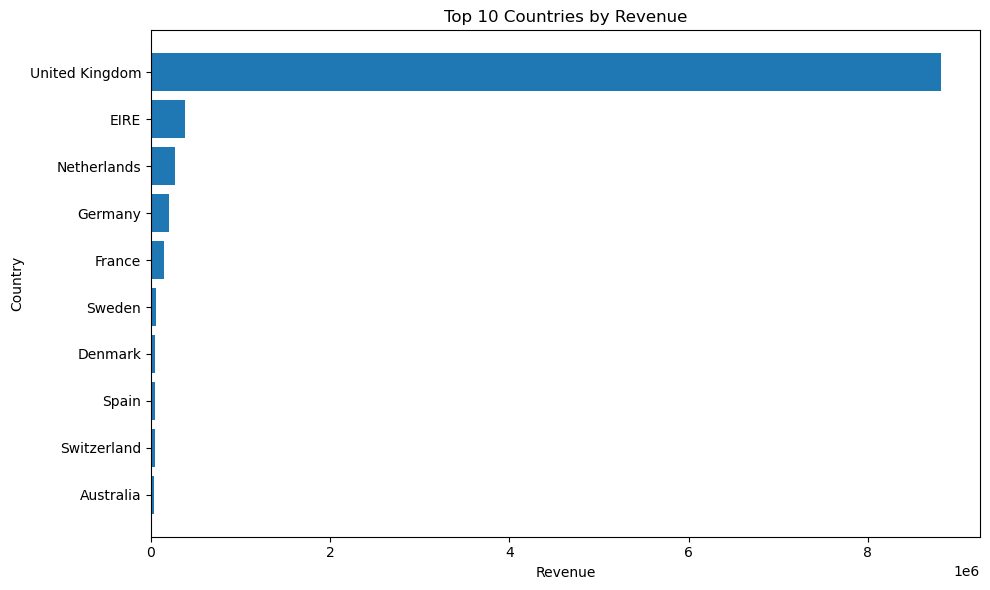

In [163]:
top_10_countries = (
    country_analysis
    .sort_values("Revenue",ascending=False)
    .head(10)
)
plt.figure(figsize=(10,6))
plt.barh(
    top_10_countries["Country"][::-1],
    top_10_countries["Revenue"][::-1]
)
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.title("Top 10 Countries by Revenue")

plt.tight_layout()
plt.show()


# CUSTOMER ANALYSIS - Build Customer-Level Summary

In [167]:
customer_summary = (
    df_sales[df_sales["Customer ID"].notna()]
    .groupby("Customer ID")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("Invoice", "nunique"),
        Units_Sold=("Quantity", "sum")
    )
    .reset_index()
)
print(customer_summary.head())

   Customer ID  Revenue  Transactions  Units_Sold
0      12346.0   372.86            11          70
1      12347.0  1323.32             2         828
2      12348.0   222.16             1         373
3      12349.0  2671.14             3         993
4      12351.0   300.93             1         261


# top 10 customers by revenue

In [168]:
Top_customers = (
    customer_summary
    .sort_values("Revenue",ascending=False)
    .head(10)
)
print(Top_customers)

      Customer ID    Revenue  Transactions  Units_Sold
4183      18102.0  349164.35            89      124216
1637      14646.0  248396.50            78      170278
1269      14156.0  196549.74           102      108105
1840      14911.0  152121.22           205       69709
939       13694.0  131443.19            94      125893
3744      17511.0   84541.17            31       55107
1951      15061.0   83284.38            86       51791
3128      16684.0   80489.21            27       54555
3177      16754.0   65500.07            29       63551
4065      17949.0   60117.60            74       30112


In [169]:
print(customer_summary[[
    "Revenue",
    "Transactions",
    "Units_Sold"
]].describe())

             Revenue  Transactions     Units_Sold
count    4312.000000   4312.000000    4312.000000
mean     2040.406712      4.455705    1280.050557
std      8911.755977      8.170213    6457.926351
min         2.950000      1.000000       1.000000
25%       307.187500      1.000000     156.000000
50%       701.615000      2.000000     380.000000
75%      1714.932500      5.000000     992.000000
max    349164.350000    205.000000  220600.000000


# How many customers are one-time buyers vs repeat customers?

In [171]:
customer_summary["Customer_Type"] = np.where(
    customer_summary["Transactions"] == 1,
    "One-Time Customer",
    "Repeat Customer"
)
print(customer_summary["Customer_Type"].value_counts())

Customer_Type
Repeat Customer      2893
One-Time Customer    1419
Name: count, dtype: int64


# calculate the percentage:

In [172]:
customer_type_pct = (
    customer_summary["Customer_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(customer_type_pct)

Customer_Type
Repeat Customer      67.09
One-Time Customer    32.91
Name: proportion, dtype: float64


# Compare revenue from each group

In [175]:
customer_type_revenue = (
    customer_summary
    .groupby("Customer_Type")
    .agg(
         Customers=("Customer ID", "count"),
        Revenue=("Revenue", "sum"),
        Transactions=("Transactions", "sum")
    )
    .reset_index()
)
customer_type_revenue["Revenue%"] = (
    customer_type_revenue["Revenue"]
    / customer_type_revenue["Revenue"].sum()
    * 100
)
print(customer_type_revenue)

       Customer_Type  Customers      Revenue  Transactions   Revenue%
0  One-Time Customer       1419   496304.474          1419   5.640956
1    Repeat Customer       2893  8301929.270         17794  94.359044


In [176]:
top_customers = (
    customer_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
)

print(top_customers)

      Customer ID    Revenue  Transactions  Units_Sold    Customer_Type
4183      18102.0  349164.35            89      124216  Repeat Customer
1637      14646.0  248396.50            78      170278  Repeat Customer
1269      14156.0  196549.74           102      108105  Repeat Customer
1840      14911.0  152121.22           205       69709  Repeat Customer
939       13694.0  131443.19            94      125893  Repeat Customer
3744      17511.0   84541.17            31       55107  Repeat Customer
1951      15061.0   83284.38            86       51791  Repeat Customer
3128      16684.0   80489.21            27       54555  Repeat Customer
3177      16754.0   65500.07            29       63551  Repeat Customer
4065      17949.0   60117.60            74       30112  Repeat Customer


# Calculate the percentages explicitly

In [177]:
customer_type_revenue["Customer_%"] = (
    customer_type_revenue["Customers"]
    / customer_type_revenue["Customers"].sum()
    * 100
)

print(customer_type_revenue)

       Customer_Type  Customers      Revenue  Transactions   Revenue%  \
0  One-Time Customer       1419   496304.474          1419   5.640956   
1    Repeat Customer       2893  8301929.270         17794  94.359044   

   Customer_%  
0   32.908163  
1   67.091837  


In [178]:
print(df_sales.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Transaction_Type', 'Revenue',
       'Year', 'Month', 'Month_Name', 'Year_Month', 'Day_Of_Week', 'Hour',
       'Day_of_Week'],
      dtype='object')


In [179]:
df_sales = df_sales.rename(columns={
    "Customer ID": "Customer_ID"
})

In [180]:
print(df_sales.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country', 'Transaction_Type', 'Revenue',
       'Year', 'Month', 'Month_Name', 'Year_Month', 'Day_Of_Week', 'Hour',
       'Day_of_Week'],
      dtype='object')


In [181]:
print((df_sales["Day_Of_Week"] == df_sales["Day_of_Week"]).all())

True


In [182]:
df_sales = df_sales.drop(columns=["Day_of_Week"])

In [183]:
df_sales.to_csv("online_retail_sql.csv", index=False)

# Find where the CSV was saved

In [184]:
import os

print(os.path.abspath("online_retail_sql.csv"))

/Users/shivi/online_retail_sql.csv


In [185]:
print(len(df_sales))

504731


In [186]:
import pandas as pd

df_check = pd.read_csv("online_retail_sql.csv")

print(df_check.shape)
print(df_check.columns.tolist())

(504731, 16)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country', 'Transaction_Type', 'Revenue', 'Year', 'Month', 'Month_Name', 'Year_Month', 'Day_Of_Week', 'Hour']


/var/folders/82/6rq2dldj5vxfz2191z6z1jfr0000gn/T/ipykernel_57090/2204681066.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_check = pd.read_csv("online_retail_sql.csv")


In [187]:
print(df_check.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country', 'Transaction_Type', 'Revenue', 'Year', 'Month', 'Month_Name', 'Year_Month', 'Day_Of_Week', 'Hour']
